# Section 2 — Cleaning, Wrangling & Preprocessing


These are our next steps after being informed by our EDA:
1. Load Data 
2. Drop null and duplicates
2. Drop irrelevant columns 
3. Correlation Check
4. Scaling Features
5. Save EDA-Informed DataSet
6. PCA
7. Save PCA-transformed DataSet



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
# Style for visuals
PALETTE = sns.color_palette('husl', 15)
plt.style.use('dark_background')

## 1. Load Data

In [2]:
df = pd.read_csv('../data/train.csv')
print(df.shape) # 24 columns, 28362 rows
df.head()

(28362, 24)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


## 2. Check for Nulls & Duplicates

In [3]:
print(f"Count of Null Values: {df.isnull().sum()}")
print("----")
print(f"Count of Duplicates: {df.duplicated().sum()}")

Count of Null Values: Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64
----
Count of Duplicates: 0


## 3. Drop Columns

From our lectures, we discussed how **Standardization** is dependent on which insights we like to capture. If we **dont** scale `len` = clusters will be heavily influenced by song length
<br>

So, we can either scale `len` because it has a different scale than lyrical features or we can drop it.
<br>

Although `len` carries some thematic signal through its correlation with `obscene` (r = 0.44), it ultimately measures song length rather than lyrical content. Since our goal is to cluster by lyrical themes, we drop `len` to keep the feature set intentional and consistent.



In [4]:
# Dropping the following columns based on EDA:
# 'Unnamed: 0'   - not informative, likely row index
# 'artist_name'  - identifier
# 'track_name'   - identifier
# 'lyrics'       - raw text
# 'age'          - confirmed redundant with release_date
# 'release_date' - could cause clusters to reflect era not lyrical content
# 'topic'        - derived directly from lyrical scores
# 'len'          - CHECK WHY THIS IS DROPPED ABOVE!

cols_to_drop = ['Unnamed: 0', 'artist_name', 'track_name', 'lyrics', 'age', 
                'release_date','topic', 'len']

df_clean = df.drop(columns=cols_to_drop)

print(f'Shape after dropping columns: {df_clean.shape}') # From 24 to 17 columns
print(df_clean.columns.tolist())

Shape after dropping columns: (28362, 16)
['genre', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings']


In [5]:
lyrical_cols = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience',
    'family/gospel', 'romantic', 'communication', 'obscene', 'music',
    'movement/places', 'light/visual perceptions', 'family/spiritual',
    'sadness', 'feelings'
]

numeric_cols = df_clean[lyrical_cols]
print(numeric_cols.columns)

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings'],
      dtype='object')


We wont be including `genre` in our training because it is essentially a label that describes the same thing our clusters are trying to discover.  
`genre` as a clustering feature would be cheating the unsupervised process - the clusters would just end up reflecting genre boundaries we already know exist (basically give the model a strong hint on how songs should be grouped), rather than discovering hidden patterns in the lyrical content on its own.

The whole point of unsupervised learning here is to let the model find structure without being told what the groups should look like. Including `genre` would preempt that.

## 4. Correlation Check

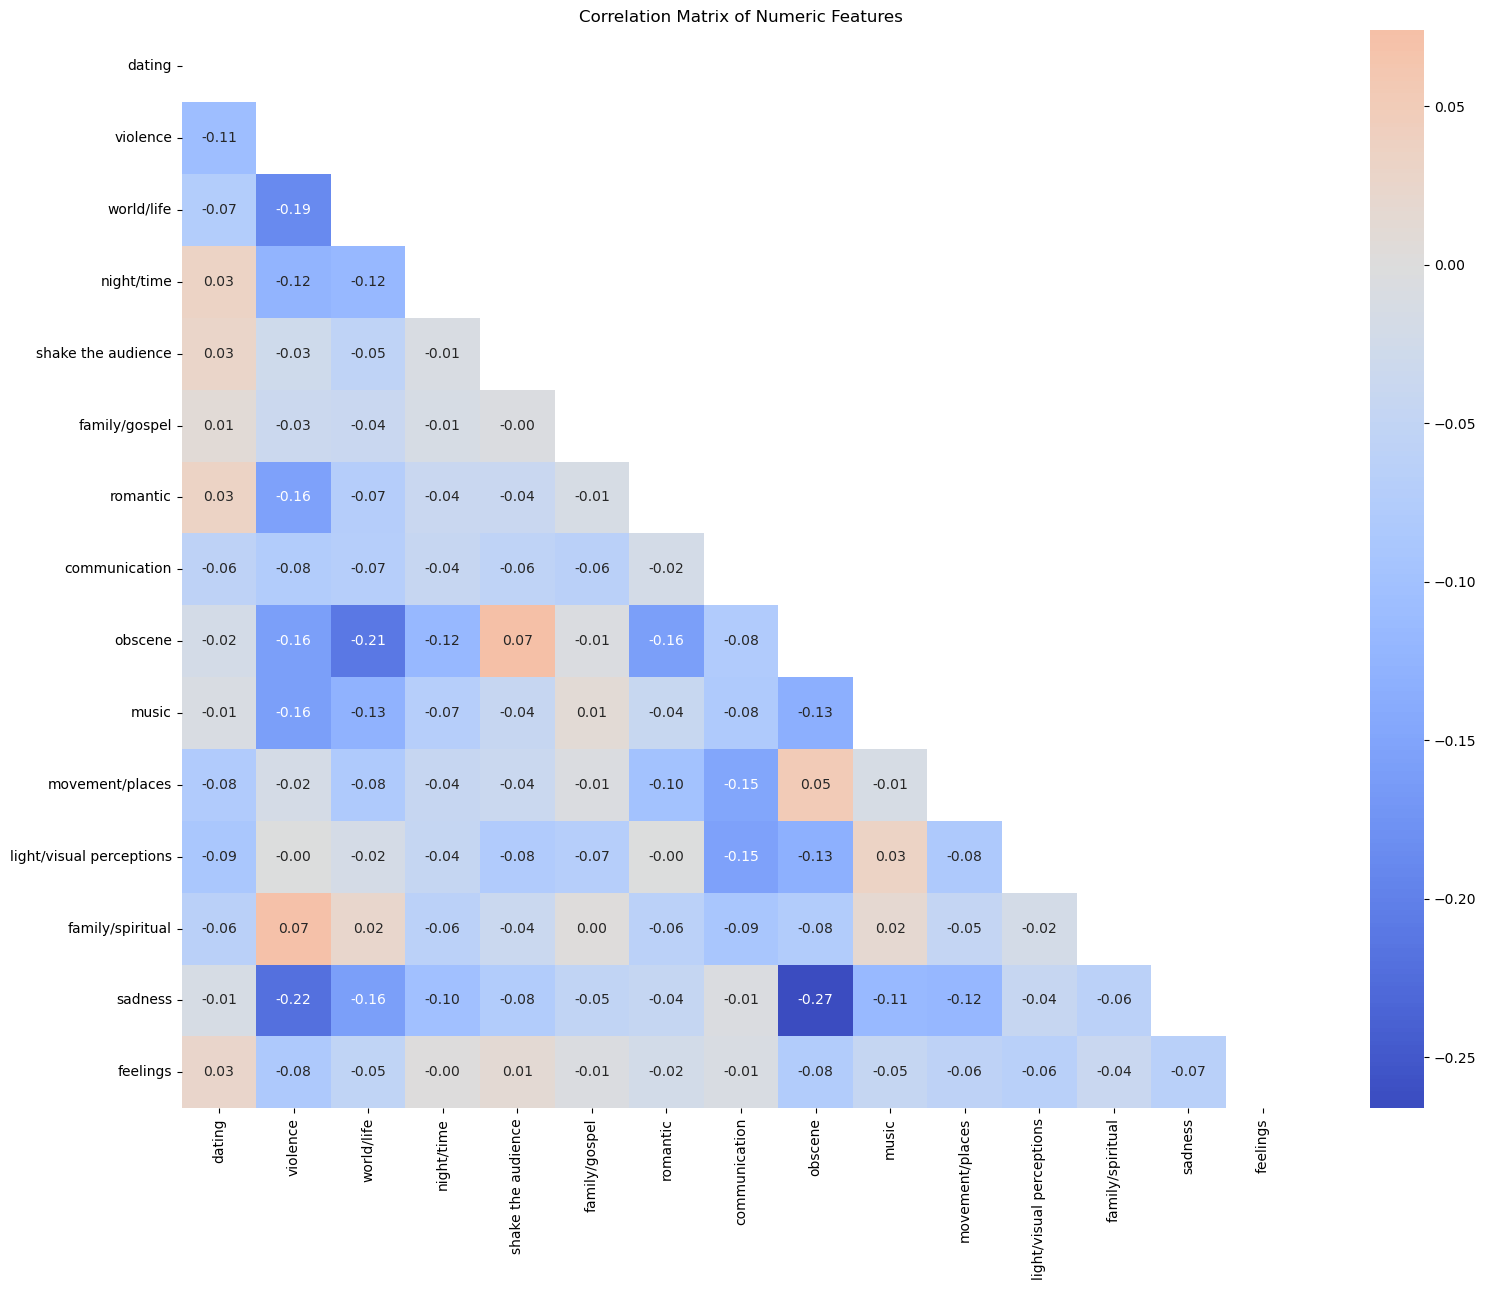

In [6]:
# confirm that no pair exceeds r=0.5
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

plt.figure(figsize=(16,13))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 5. Scaling Features

- Our 15 lyrical features are all already on the same 0–1 scale. No standardization needed between them since they're naturally comparable.
- We dropped `len`, which was the only column on a different scale (1–199), removing the only reason we would have needed scaling.
- Since KMeans uses distance to group songs, having all features on the same 0–1 scale already means no single feature will dominate the distance calculation.
- Our goal is to cluster by lyrical themes, so we want each of the 15 features to contribute equally which they already do without any additional transformation.

## 6. Save New Dataset (with EDA-Informed Features) to New CSV File

In [ ]:
df_clean.to_csv('../data/cleaned_data/cleaned_train.csv', index=False) # 15 lyrical features from EDA + genre
print(f'Saved cleaned_train.csv — shape: {df_clean.shape}')

Saved cleaned_train.csv — shape: (28362, 16)


## 7. PCA - Dimensionality Analysis

Since our correlations are already low, do we even need to do this? 
PCA helps reduce dimensionality by compressing them down into the most important ones. It's harder to classify which group a sample belongs to as we add more dimensions to our dataset.

**We may as well try both to see if we can get the best sillhouette score.**

In [8]:
# Step 1 — fit PCA on all 15 components to see variance explained
pca_full = PCA(random_state=42)
pca_full.fit(numeric_cols.values)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

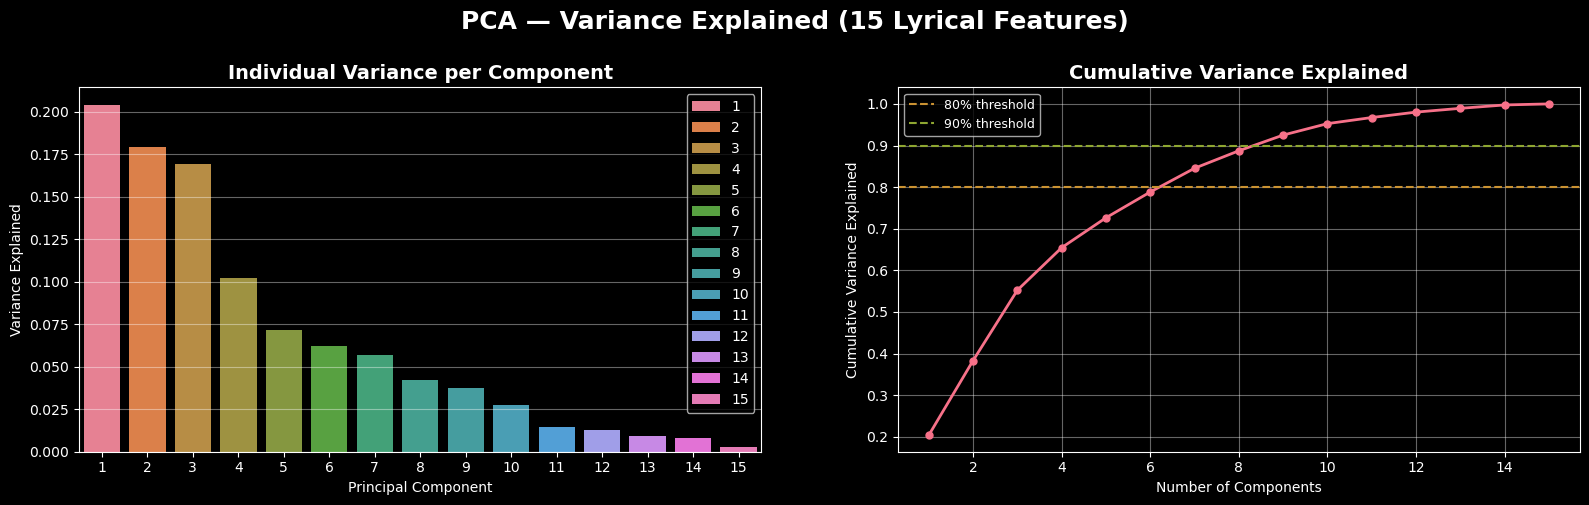

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
num_components = range(1, 16) # 15 components since we have 15 features


# INDIVIDUAL VARIANCE PER COMPONENT
# after transforming the lyrical features, how much does each new component contribute?
sns.barplot(x=list(num_components), y=explained, ax=ax[0], hue=num_components, 
            palette=PALETTE[:len(num_components)], edgecolor=None)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Variance Explained')
ax[0].set_title('Individual Variance per Component', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.4)



# CUMULATIVE VARIANCE
ax[1].plot(num_components, cumulative, color=PALETTE[0], 
           linewidth=2, marker='o', markersize=5)
ax[1].axhline(0.80, color=PALETTE[2], linestyle='--', linewidth=1.5, label='80% threshold')
ax[1].axhline(0.90, color=PALETTE[4], linestyle='--', linewidth=1.5, label='90% threshold')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Cumulative Variance Explained')
ax[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.4)



plt.suptitle('PCA — Variance Explained (15 Lyrical Features)', y=1, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

Individual variance per component
- Each bar gets noticeably smaller after the first 3 components *(meaning the remaining components are adding less and less new information)*

Cumulative variance
- The first 3 components alone capture over 55% of the variance, meaning they hold the most information from our 15 features.
- We need 7 components to cross the 80% threshold and 9 for 90% — meaning PCA doesn't compress our data very efficiently, which is expected given our low feature correlations.

In [10]:
# Step 3 — pick number of components (80% threshold = 7 components)
n_components = np.argmax(cumulative >= 0.80) + 1
print(f'Components needed for 80% variance: {n_components}')

Components needed for 80% variance: 7


In [11]:
# Step 4 — refit PCA with chosen number of components
pca = PCA(n_components=n_components, random_state=42)
numeric_cols_pca = pca.fit_transform(numeric_cols.values)

print(f'PCA feature matrix shape: {numeric_cols_pca.shape}')

PCA feature matrix shape: (28362, 7)


## 8. Save New Dataset (with PCA-Transformed Features) to New CSV File

In [ ]:
# Step 5 — save as dataframe
pca_cols = [f'PC{i+1}' for i in range(n_components)]

df_pca = pd.DataFrame(numeric_cols_pca, columns=pca_cols)
df_pca['genre'] = df_clean['genre'].values

df_pca.to_csv('../data/cleaned_data/cleaned_train_pca.csv', index=False)
print(f'Saved cleaned_train_pca.csv — shape: {df_pca.shape}')

Saved cleaned_train_pca.csv — shape: (28362, 8)
